# Chapter 5: Language Models for Test-Space Discovery

A search that only moves candidates within a fixed structure cannot find a failure the structure cannot express. Chapter 5 introduces structural discovery: a proposer, here a language model, reads discovery evidence and proposes a revised search-space specification, which is admitted by explicit checks and returned to numerical optimization. The chapter's executed case applies this to the medoid search of Chapter 4, where one live call proposed allowing a weak region to be a union of two cells.

This notebook follows that proposal through its evidence, admission, matched-budget search and confirmation. It reads the saved response and packet, checks the admission record, compares construction costs, recomputes and redraws the discovery frontiers and the confirmation results and assesses the proposal's stated prediction. It makes no new language-model call, and no model is fitted.

**Evidence.** The records are in `book/evidence/aml_medoid_loop_leaf_output_20260921/`, the run used in Chapters 2 and 4, with the reflection records in its `reflection/` folder. The population is synthetic. The predictor and the auxiliary error model are frozen, and Chapter 3's corrected geometry belongs to a different run.

**Run order.** Run the cells from top to bottom. Each assertion checks a recomputed quantity against the saved record or a value printed in the chapter.

## Setup and source checks

Use a Python kernel with the dependencies listed in the README. The setup cell locates the data root, which holds the evidence files and helper modules. It uses `MODEL_VALIDATION_ROOT` when that variable is set. Otherwise it searches for a repository checkout containing the current directory and then for the copy installed with the `aiv` package.

`load()` reads the protocol, confirmation results and frozen finalists and checks the SHA-256 digests that link them to the predictor, the auxiliary models and the admission record. It also checks that the admission record names the digest of the saved response. A failed assertion means a file differs from the recorded run.

In [1]:
from pathlib import Path
import os
import platform
import sys
import importlib.util

# Locate the data root: the directory whose relative layout the evidence records use.
MARKER = "book/notebooks/regional_case/companion.py"

def find_data_root():
    configured = os.environ.get("MODEL_VALIDATION_ROOT")
    if configured:
        root = Path(configured).expanduser().resolve()
        if not (root / MARKER).is_file():
            raise FileNotFoundError(f"MODEL_VALIDATION_ROOT must contain {MARKER}")
        return root, "MODEL_VALIDATION_ROOT"
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / MARKER).is_file():
            return path, "repository checkout"
    try:
        from aiv.companions import locate
    except ImportError:
        raise FileNotFoundError(
            "Companion data not found. Install the aiv package, open the notebook "
            "inside the repository checkout, or set MODEL_VALIDATION_ROOT.") from None
    return locate()

ROOT, DATA_SOURCE = find_data_root()
HELPERS = ROOT / "book/notebooks/regional_case"
for path in (ROOT, ROOT / "book", HELPERS):
    value = str(path)
    if value in sys.path:
        sys.path.remove(value)
    sys.path.insert(0, value)

# Load current helper files even if this kernel cached an older notebook revision.
def load_helper_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    try:
        spec.loader.exec_module(module)
    except Exception:
        sys.modules.pop(name, None)
        raise
    return module

load_helper_module("companion", HELPERS / "companion.py")
load_helper_module("ch02_helpers", HELPERS / "ch02_helpers.py")
load_helper_module("weighted_leaf_geometry", ROOT / "book/weighted_leaf_geometry.py")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
print("Python:", platform.python_version())
print("Data root found from:", DATA_SOURCE)
from companion import RUN, read, load, frontier, confirmation, measure, assignments
pd.set_option("display.float_format", "{:.6f}".format)
protocol, results, frozen = load()
print("Evidence:", RUN.relative_to(ROOT).as_posix())
print("Mode: saved-evidence replay; no fitting or live LLM calls")


Python: 3.12.3
Data root found from: repository checkout
Evidence: book/evidence/aml_medoid_loop_leaf_output_20260921
Mode: saved-evidence replay; no fitting or live LLM calls


## Read the proposal

The medoid search of Chapter 4 restricts every region to one cell of a four-medoid partition. Replacing medoids moves the cell boundaries, but it cannot express a region that consists of two separated groups with elevated error. Chapter 5 calls a change of this kind a structural revision: it alters what the constructor can build rather than which candidate is built (Section 5.1). A language model is used here as the Discovery Proposer. It reads a packet of discovery evidence and proposes one revision, which is then admitted or rejected by explicit checks and evaluated numerically (Section 5.12.2).

After the ordinary searches, one live call received the current specification, feature definitions and discovery records from the three twinning-seeded runs. The permitted options were one derived feature from two observed fields, unions of up to two cells or retention of the current structure. The prompt expressed no preference among them. This notebook reads the saved response and the saved packet; it makes no new call.

The first display is the response as recorded: the proposed change, its rationale, the evidence identifiers it cites, a falsifiable prediction, alternative explanations and stated limitations. The table recomputes, from the packet, the values the rationale quotes: each run's selected contrast and share and two feature medians of the selected region. The assertions check the parent specification, the cited evidence identifiers and every quoted value.

In [2]:
response=read(RUN/"reflection/response.json")
packet=read(RUN/"reflection/packet.json")
display(response)
rows=[dict(run=r["evidence_id"],contrast=r["primary"]["region"]["contrast"],share=r["primary"]["region"]["share"],
           business_receipt_share=r["region_medians"]["business_receipt_share"],
           documentation_gap_z=r["region_medians"]["documentation_gap_z"]) for r in packet["runs"]]
display(pd.DataFrame(rows))
assert response["parent_specification"]==packet["parent_specification"]=="leaf-output-medoid-single-cell-v1"
assert set(response["evidence_ids"])-{"design"}=={r["run"] for r in rows}
# Values quoted in the chapter: contrasts 0.0573-0.0616, shares 11.56%-12.43%,
# and the third run's medians 0.709 and 0.847 against about 0.274 and 1.46.
assert (round(min(r["contrast"] for r in rows),4),round(max(r["contrast"] for r in rows),4))==(0.0573,0.0616)
assert (round(100*min(r["share"] for r in rows),2),round(100*max(r["share"] for r in rows),2))==(11.56,12.43)
assert (round(rows[2]["business_receipt_share"],3),round(rows[2]["documentation_gap_z"],3))==(0.709,0.847)
assert all(round(r["business_receipt_share"],3) in (0.273,0.274) and round(r["documentation_gap_z"],2)==1.46 for r in rows[:2])
print("Excluded from the packet:",packet["excluded"])

{'parent_specification': 'leaf-output-medoid-single-cell-v1',
 'change_type': 'union_cells',
 'operation': 'none',
 'operands': [],
 'feature_name': '',
 'rationale': 'Permit a weak region to contain up to two cells of the same four-medoid partition, keeping the auxiliary embedding and predictive model fixed. Across seeds, selected single cells have similar contrasts (0.0573–0.0616) and shares (11.56%–12.43%), but different profiles: business_receipt_share has median 0.709 in run:73103 versus approximately 0.274 in the other runs, while documentation_gap_z is 0.847 versus approximately 1.46. Together with much higher contrasts in small frontier cells, this motivates testing whether distinct error-associated profiles can jointly form a supported region without the dilution required by one nearest-medoid cell. Medoid replacement can move cell boundaries but cannot directly express a union. This is a hypothesis about representational capacity, not evidence that numerical optimization reac

,run,contrast,share,business_receipt_share,documentation_gap_z
0,run:73101,0.061616,0.115625,0.273062,1.459000
1,run:73102,0.057295,0.124100,0.274151,1.463543
2,run:73103,0.060556,0.124300,0.708694,0.846813


Excluded from the packet: No confirmation observations, simulation rules, hidden groups or author-preferred transformation supplied.


**Read the output.** The response proposes `union_cells`: a region may contain up to two cells of the same partition, with the predictor and the auxiliary embedding unchanged. The three selected regions have similar contrasts (0.057295 to 0.061616) and shares (11.56% to 12.43%), but the seed-73103 region has a different profile: median business-receipt share 0.708694 and documentation gap 0.846813, against about 0.274 and 1.46 in the other two runs. The response reads this as a sign that distinct error-associated groups exist that a single cell cannot collect. It also lists competing explanations, including incomplete optimization and dilution of contrast by a second cell. It states that the packet lacked cell-level losses and overlaps, so it could not show that a useful union exists. The printed exclusion line confirms that no confirmation data, simulation rules or hidden group labels were supplied. The rationale is therefore a hypothesis formed from discovery records.

## Check admission

A proposal changes the test space only after admission (Section 5.9). Admission asks whether the revised specification can be executed and scored under the existing measurement contract; it does not ask whether the proposal's explanation is correct. The checks are recorded in `admission.json`, and `structural_checks.json` records the machine checks on the response itself.

The first assertion ties the admission record, the structural checks and the saved response together by the response's SHA-256 digest, so the admitted proposal is exactly the response displayed above. The second requires that admission succeeded, that the structural checks passed and that the call used no tools. The cell then prints the parent and new specification versions, each admission check and the stated reason.

In [3]:
admission=read(RUN/"reflection/admission.json")
checks=read(RUN/"reflection/structural_checks.json")
from companion import sha
assert admission["response_sha256"]==checks["response_sha256"]==sha(RUN/"reflection/response.json")
assert admission["admitted"] and checks["passed"] and not checks["tools_used"]
print("Parent:",admission["parent"])
print("New version:",admission["version"])
for check in admission["checks"]:print(" -",check)
print("Reason:",admission["reason"])

Parent: leaf-output-medoid-single-cell-v1
New version: leaf-output-medoid-union-v1
 - schema, parent version and supplied evidence IDs passed
 - two cells must come from the same candidate partition
 - no outcome-dependent membership or new measurements
 - four singles and six pairs charged per partition
 - new confirmation seed 62491 after all finalist choices freeze
Reason: A union of at most two cells from the same four-medoid partition preserves the frozen logistic predictor, auxiliary leaf-output embedding, observed covariates, Brier loss reference and all support checks. Membership uses only covariates and frozen output-space medoids. The new rule can be executed and scored without any new measurements. The fragmentation mechanism and performance prediction remain unverified.


**Read the output.** Admission creates version `leaf-output-medoid-union-v1` from parent `leaf-output-medoid-single-cell-v1`. The checks require both cells to come from the same partition, forbid outcome-dependent membership and new measurements, charge four singles and six pairs per partition and fix a new confirmation seed, 62491, to be used only after all finalists freeze. The reason explains why the union rule is admissible: membership still uses only covariates and the frozen output-space medoids, and the predictor, embedding, Brier reference and support checks are unchanged. The final sentence of the reason separates admissibility from the hypothesis: the fragmentation mechanism and the performance prediction remain unverified.

## Compare construction costs

The revised rule and ordinary continuation must be compared at equal cost. Under the union rule a partition of four cells exposes $\binom{4}{1}=4$ single cells and $\binom{4}{2}=6$ pairs, and each of these ten candidate regions requires a region score. Each branch receives 1,600 additional region scores per seed.

The table lists, for both branches and all seeds, the maximum number of cells in a region, the inherited history, the number of newly evaluated partitions and the region-score budget. The assertions check that continuation spends its budget on 400 partitions at four scores each and the union branch on 160 partitions at ten scores each.

In [4]:
from itertools import combinations
singles,pairs=list(combinations(range(4),1)),list(combinations(range(4),2))
print("Singles:",singles)
print("Pairs:",pairs)
runs={(arm,seed):read(RUN/f"{arm}_{seed}.json") for arm in ["continuation","reflection"] for seed in protocol["seeds"]}
budget=pd.DataFrame([dict(arm=arm,seed=seed,max_union=r["max_union"],inherited=r["inherited_candidates"],
                          added_partitions=r["added_candidate_evaluations"],region_budget=r["region_score_budget"])
                     for (arm,seed),r in runs.items()])
display(budget)
assert (budget.region_budget==1600).all()
assert (budget[budget.arm=="continuation"].added_partitions*4==1600).all()
assert (budget[budget.arm=="reflection"].added_partitions*(len(singles)+len(pairs))==1600).all()

Singles: [(0,), (1,), (2,), (3,)]
Pairs: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]


,arm,seed,max_union,inherited,added_partitions,region_budget
0,continuation,73101,1,400,400,1600
1,continuation,73102,1,400,400,1600
2,continuation,73103,1,400,400,1600
3,reflection,73101,2,0,160,1600
4,reflection,73102,2,0,160,1600
5,reflection,73103,2,0,160,1600


**Read the output.** Continuation extends its complete 400-candidate history by 400 partitions. The union branch starts a new history under the new version. It rescores the prior selected medoids and additional seed sets and then evaluates 160 partitions. The budgets agree in region scores. They differ in the number of partitions explored, and neither count includes elapsed time or the cost of the language-model call. The comparison therefore tests the admitted extension against continued search under one declared cost measure.

## Redraw the discovery frontiers

The first evidence of the union rule's effect comes from discovery. For each seed the cell recomputes three frontiers from the saved histories: the original twinning search, continuation and the union branch. Their frontier areas summarize them. With frontier members ordered by increasing share $\pi_1<\dots<\pi_m$ and contrasts $\Delta_1,\dots,\Delta_m$, the area is

$$\sum_{j=1}^{m}\max(\Delta_j,0)\,(\pi_j-\pi_{j-1}),\qquad \pi_0=0,$$

the area under the frontier's step function, which increases when the frontier moves outward anywhere along the share axis. The assertions check each recomputed frontier and area against the saved values and the chapter's reported counts and areas.

The plot reproduces Figure 5.3 inline: open squares mark two-cell regions on the union branch's frontier, and the dotted line marks the 10% share floor of the primary policy. Nothing is written to the evidence folder.

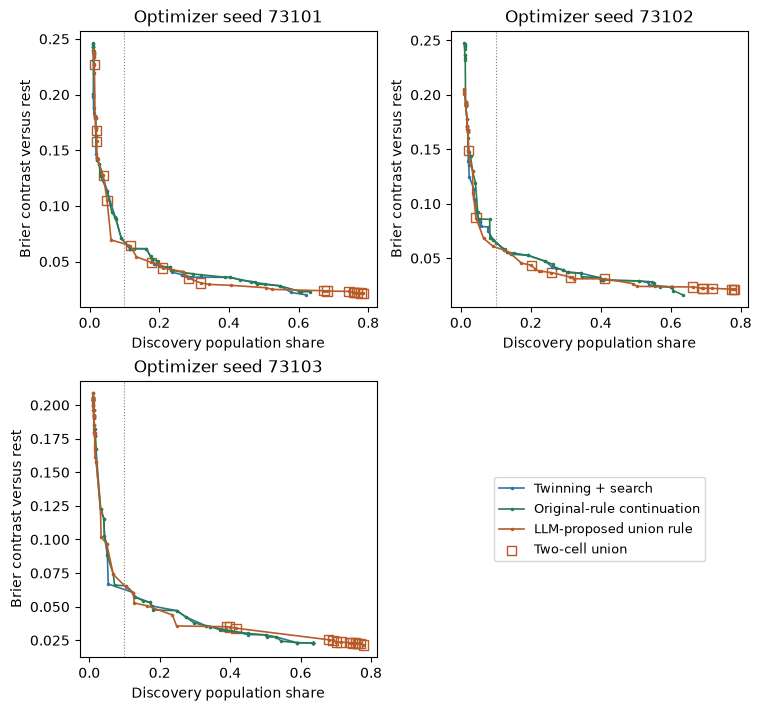

,seed,arm,frontier_size,two_cell_regions,frontier_area
0,73101,twinning,39,0,0.030876
1,73101,continuation,54,0,0.032106
2,73101,reflection,42,18,0.032665
3,73102,twinning,48,0,0.029246
4,73102,continuation,61,0,0.031247
5,73102,reflection,46,13,0.030970
6,73103,twinning,39,0,0.029339
7,73103,continuation,54,0,0.030133
8,73103,reflection,48,13,0.032418


In [5]:
colors={"twinning":"#3174a1","continuation":"#287c50","reflection":"#b85b28"}
names={"twinning":"Twinning + search","continuation":"Original-rule continuation","reflection":"LLM-proposed union rule"}
def area(front):
    prev=total=0.
    for r in front:
        total+=max(r["objectives"][0],0)*(r["objectives"][1]-prev);prev=r["objectives"][1]
    return total
fig,grid=plt.subplots(2,2,figsize=(7.5,7),constrained_layout=True)
axs=list(grid.flat[:3]);grid.flat[3].axis("off");rows=[]
for ax,seed in zip(axs,protocol["seeds"]):
    for arm in ["twinning","continuation","reflection"]:
        r=read(RUN/f"{arm}_{seed}.json");f=frontier(r["records"])
        assert [x["id"] for x in f]==r["frontier_ids"]
        np.testing.assert_allclose(area(f),r["hypervolume"],rtol=1e-12)
        ax.plot([v["objectives"][1] for v in f],[v["objectives"][0] for v in f],".-",color=colors[arm],label=names[arm],linewidth=1.2,markersize=3)
        unions=[v for v in f if len(v["region"]["cells"])==2]
        if arm=="reflection":
            ax.scatter([v["objectives"][1] for v in unions],[v["objectives"][0] for v in unions],marker="s",facecolors="none",edgecolors=colors[arm],s=45,label="Two-cell union")
        rows.append(dict(seed=seed,arm=arm,frontier_size=len(f),two_cell_regions=len(unions),frontier_area=r["hypervolume"]))
    ax.axvline(.1,color="gray",linestyle=":",linewidth=.8)
    ax.set(xlabel="Discovery population share",ylabel="Brier contrast versus rest",title=f"Optimizer seed {seed}")
handles,labels=axs[0].get_legend_handles_labels();grid.flat[3].legend(handles,labels,loc="center",fontsize=9)
plt.show()
fronts=pd.DataFrame(rows);display(fronts)
ext=fronts[fronts.arm=="reflection"];cont=fronts[fronts.arm=="continuation"]
assert list(ext.two_cell_regions)==[18,13,13]
assert [round(x,6) for x in ext.frontier_area]==[0.032665,0.030970,0.032418]
assert [round(x,6) for x in cont.frontier_area]==[0.032106,0.031247,0.030133]

**Read the output.** The union branch retains 18, 13 and 13 two-cell regions on its frontiers, so the new rule does express tradeoffs that single cells did not reach. Its frontier area, 0.032665, 0.030970 and 0.032418, exceeds continuation's 0.032106 and 0.030133 at seeds 73101 and 73103 and falls below continuation's 0.031247 at seed 73102. Both branches exceed the original twinning search, which had only 1,600 region scores. These are adaptive discovery measurements on the sample that guided both searches, so they indicate where to look but do not establish that the union rule finds weaker regions in new data.

## Assess the prediction

The response predicted that the union-enabled search would find a region with greater Brier contrast than equal-budget continuation, and that the improvement would persist on independent confirmation. Each branch froze its primary selection under the same policy before the 200,000 confirmation observations were generated. The paired difference, structural minus continued contrast, is estimated on the same confirmation rows with the Bonferroni simultaneous intervals used throughout the study.

The table shows, for each seed, the cells of the structural selection, both confirmation contrasts, their difference and its interval. The assertions check every value against Table 5.4 of the chapter and require that each interval contain zero. All three comparisons are retained, including the negative one.

In [6]:
paired=pd.DataFrame([r for r in results["comparisons"] if r["a"]=="reflection"])
paired["continued"]=[results["confirmation"][f"continuation_{s}"]["contrast"] for s in paired.seed]
paired["structural"]=[results["confirmation"][f"reflection_{s}"]["contrast"] for s in paired.seed]
paired["cells"]=[next(r for r in frozen["finalists"] if r["key"]==f"reflection_{s}")["discovery"]["region"]["cells"] for s in paired.seed]
display(paired[["seed","cells","continued","structural","contrast_difference","simultaneous_ci"]])
table={73101:(0.057940,0.058326,0.000386,[-0.001723,0.002495]),73102:(0.057581,0.053993,-0.003587,[-0.007844,0.000669]),
       73103:(0.060226,0.062599,0.002373,[-0.000913,0.005660])}
for _,r in paired.iterrows():
    assert (round(r.continued,6),round(r.structural,6),round(r.contrast_difference,6),[round(x,6) for x in r.simultaneous_ci])==table[r.seed]
assert all(lo<=0<=hi for lo,hi in paired["simultaneous_ci"])
assert list(paired.cells)==[[2,3],[1],[3]]
print(results["scope"])

,seed,cells,continued,structural,contrast_difference,simultaneous_ci
0,73101,"[2, 3]",0.057940,0.058326,0.000386,"[-0.0017229699434947615, 0.002494938298177806]"
1,73102,[1],0.057581,0.053993,-0.003587,"[-0.007844142850882287, 0.0006693758879839432]"
2,73103,[3],0.060226,0.062599,0.002373,"[-0.0009134492359307404, 0.005659536806161127]"


Three optimizer seeds share one discovery sample, one reflection and one confirmation sample; not independent study replications.


**Read the output.** The structural branch selects a two-cell union, cells [2, 3], only at seed 73101; at the other seeds its best eligible region is a single cell. The differences are 0.000386, −0.003587 and 0.002373, and every interval contains zero. The prediction is therefore not supported in this execution: the admitted rule changed the constructor, but no primary advantage over continuation is resolved. The printed scope applies to all three seeds, which share one discovery sample, one proposal and one confirmation sample and so describe search variation under common inputs rather than independent replications.

## Redraw the confirmation figure

The paired intervals compare frozen rules, and those rules select regions of different size. The cell reproduces Figure 5.4, which shows for every arm and seed the confirmation contrast with its simultaneous interval (left) and the region's confirmation share (right). The dashed line is the subset-PAM reference and the dotted line the 10% discovery floor. The table and assertions check the coverages stated in the chapter and the confirmation design: seed 62491, 200,000 observations and a family of 19 claims.

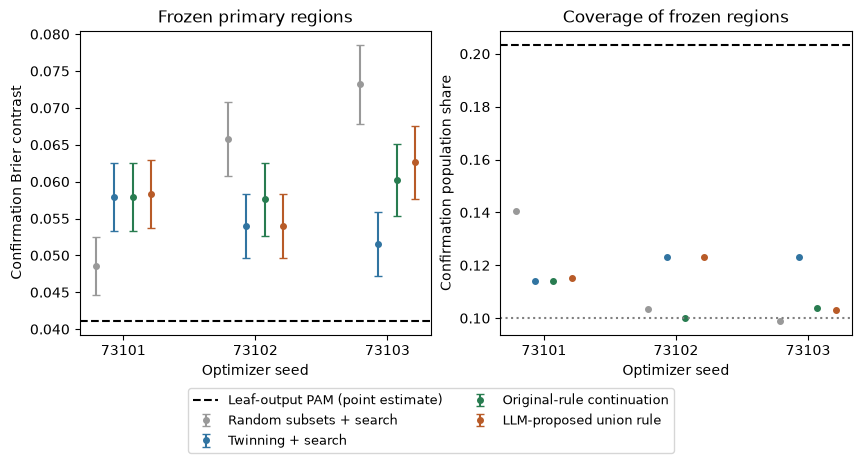

,continuation share (%),reflection share (%)
73101,11.392500,11.522000
73102,10.005000,12.310500
73103,10.394500,10.323000


In [7]:
colors["random"]="#999999";names["random"]="Random subsets + search"
fig,axs=plt.subplots(1,2,figsize=(8.5,4.5),constrained_layout=True)
for arm,offset in [("random",-.21),("twinning",-.07),("continuation",.07),("reflection",.21)]:
    rows=[results["confirmation"][f"{arm}_{s}"] for s in protocol["seeds"]]
    vals=np.array([r["contrast"] for r in rows]);lo=np.array([r["simultaneous_ci"][0] for r in rows]);hi=np.array([r["simultaneous_ci"][1] for r in rows])
    axs[0].errorbar(np.arange(3)+offset,vals,yerr=[vals-lo,hi-vals],fmt="o",color=colors[arm],label=names[arm],markersize=4,capsize=3)
    axs[1].plot(np.arange(3)+offset,[r["share"] for r in rows],"o",color=colors[arm],markersize=4)
pam=results["confirmation"]["pam"]
axs[0].axhline(pam["contrast"],linestyle="--",color="black",label="Leaf-output PAM (point estimate)")
axs[1].axhline(pam["share"],linestyle="--",color="black")
axs[1].axhline(.1,linestyle=":",color="gray",label="Discovery selection floor")
for ax in axs:ax.set(xticks=range(3),xticklabels=[str(s) for s in protocol["seeds"]],xlabel="Optimizer seed")
axs[0].set(ylabel="Confirmation Brier contrast",title="Frozen primary regions")
axs[1].set(ylabel="Confirmation population share",title="Coverage of frozen regions")
handles,labels=axs[0].get_legend_handles_labels();fig.legend(handles,labels,loc="outside lower center",ncol=2,fontsize=9)
plt.show()
coverage=pd.DataFrame({arm:[100*results["confirmation"][f"{arm}_{s}"]["share"] for s in protocol["seeds"]] for arm in ["continuation","reflection"]},index=protocol["seeds"])
display(coverage.rename(columns=lambda c:c+" share (%)"))
stated={"reflection":[11.522,12.311,10.323],"continuation":[11.393,10.005,10.395]}
for arm,values in stated.items():
    assert all(abs(a-b)<=5e-4+1e-9 for a,b in zip(coverage[arm],values))
assert protocol["confirmation_seed"]==62491 and protocol["confirmation_n"]==200000
assert results["family_size"]==19

**Read the output.** The structural regions cover 11.522%, 12.311% and 10.323% of the confirmation sample, and the continued regions 11.393%, 10.005% and 10.395%. At seed 73102 the structural region is about 2.3 percentage points larger and has the smaller contrast, which is consistent with the contrast–share tradeoff seen on every frontier. Because the frozen regions differ in coverage, a difference in contrast compares two rules on shared observations and should be read together with their shares. The 19-claim family comprises the 13 selected confirmation contrasts and six paired differences.

## What the replay establishes

One live proposal has been followed from its evidence packet to a measured outcome. The response proposed a construction rule, stated a falsifiable prediction and listed competing explanations. Admission checked that the rule could be executed and scored under the existing contract. Numerical search then used the admitted rule under the same region-score budget as continuation, and frozen selections were compared on fresh observations.

The rule produced two-cell regions on every discovery frontier, but the confirmation comparison did not resolve an advantage over continuation. This outcome concerns one proposal, one generator and one confirmation sample. It does not separate the language model's contribution from the value of the same rule proposed by an analyst. Chapter 6 turns to the evidence store that records these measurements with their sources.


## What to try

1. **Evidence identifiers.** Choose one identifier cited by the response (for example `run:73103`) and find its entry in `packet["runs"]`. List which fields the packet supplied and which fields the response's limitations say were missing.
2. **Two-cell regions.** From the union-branch history of seed 73101, count the valid two-cell regions with discovery share of at least 10% and report the largest discovery contrast among them. Compare it with that seed's primary selection.
3. **Frontier area.** Recompute the frontier area of one run with `area(frontier(...))`. Explain why a larger area can coexist with a primary selection that is no better at the 10% floor.
4. **Prediction and evidence.** State which outcome in the paired table would have supported the proposal's prediction, and why a positive point estimate with an interval containing zero does not.
